# Notebook 02 - Analyse Exploratoire des Données (EDA)

**Projet** : Classification des Astéroïdes Potentiellement Dangereux (PHAs)  
**Module** : Machine Learning -- ENSA Tétouan -- Pr.Yacine EL YOUNOUSSI -- 2025-2026  
**Auteurs** : Bouchennou Ferdaouss · El Allouche Zakariyae · Tafraouti Sanae  


## Imports et configuration globale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
})
sns.set_palette("Set2")

print(" Bibliothèques chargées.")


 Bibliothèques chargées.


In [2]:
# Chargement du dataset

df = pd.read_csv("../data/dataset.csv")
print(f"Dataset complet chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(5)


Dataset complet chargé : 20,000 lignes × 27 colonnes


,absolute_magnitude_h,estimated_diameter_min_km,is_sentry_object,is_potentially_hazardous,relative_velocity_km_per_second,miss_distance_astronomical,orbiting_body,n_approaches,min_miss_distance_au,max_velocity_km_s,...,orbit_uncertainty,minimum_orbit_intersection,data_arc_in_days,orbit_class_type,diameter_mean_km,diameter_uncertainty,perihelion_to_aphelion_ratio,threat_ratio,velocity_distance_ratio,observation_reliability
0,10.39,22.210328,0,0,3.983382,0.387314,EARTH,34,0.149462,6.084052,...,0.0,0.148353,46582.0,AMO,35.937066,27.453475,0.635542,0.004128,10.284639,0.0
1,15.59,2.025606,0,0,3.752797,1.822843,JUPTR,8,1.389955,5.004842,...,0.0,0.201318,41839.0,AMO,3.277499,2.503787,0.293163,0.061424,2.058761,0.0
2,13.82,4.576727,0,0,11.268954,0.166325,EARTH,3,0.082198,11.268954,...,0.0,0.079677,39281.0,AMO,7.405299,5.657145,0.272937,0.010759,67.752490,0.0
3,9.17,38.954262,0,0,15.749851,0.028684,MARS,5,0.028684,15.749851,...,0.0,0.343339,37087.0,AMO,63.029319,48.150115,0.304450,0.005447,549.090712,0.0
4,17.37,0.892391,0,0,10.502144,0.170464,EARTH,20,0.105277,11.080933,...,0.0,0.107969,33947.0,AMO,1.443918,1.103055,0.394085,0.074775,61.609112,0.0


---
# a) Exploration Univariée

**Objectif** : Pour chaque variable du dataset, produire :
- **Variables numériques** : histogramme, boxplot, statistiques descriptives (moyenne, médiane, σ, quartiles, min/max)
- **Variables catégorielles** : diagramme en barres des fréquences, identification des modalités rares (< 1 %)


### Identification et catégorisation des variables

In [6]:
# Catégorisation des colonnes
num_cols    = df.select_dtypes(include="number").columns.tolist()
cat_cols    = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
binary_cols = [c for c in num_cols if df[c].nunique() <= 2]
cont_cols   = [c for c in num_cols if c not in binary_cols]

print(f"Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire        : {df.memory_usage(deep=True).sum() / 1e6:.2f} Mo")
print()
print(f"Variables continues  ({len(cont_cols)}) : {cont_cols}")
print(f"Variables binaires   ({len(binary_cols)}) : {binary_cols}")
print(f"Variables catégor.   ({len(cat_cols)})  : {cat_cols}")


Dimensions     : 20,000 lignes × 27 colonnes
Mémoire        : 4.48 Mo

Variables continues  (23) : ['absolute_magnitude_h', 'estimated_diameter_min_km', 'relative_velocity_km_per_second', 'miss_distance_astronomical', 'n_approaches', 'min_miss_distance_au', 'max_velocity_km_s', 'semi_major_axis', 'eccentricity', 'inclination', 'perihelion_distance', 'aphelion_distance', 'orbital_period', 'perihelion_argument', 'orbit_uncertainty', 'minimum_orbit_intersection', 'data_arc_in_days', 'diameter_mean_km', 'diameter_uncertainty', 'perihelion_to_aphelion_ratio', 'threat_ratio', 'velocity_distance_ratio', 'observation_reliability']
Variables binaires   (2) : ['is_sentry_object', 'is_potentially_hazardous']
Variables catégor.   (2)  : ['orbiting_body', 'orbit_class_type']


### Statistiques descriptives - Variables continues

In [8]:
desc = df[cont_cols].describe(percentiles=[0.25, 0.50, 0.75]).T
desc.columns = ["N", "Moyenne", "Écart-type", "Min", "Q1 (25%)", "Médiane", "Q3 (75%)", "Max"]
desc["N"] = desc["N"].astype(int)
display(desc.round(4))


,N,Moyenne,Écart-type,Min,Q1 (25%),Médiane,Q3 (75%),Max
absolute_magnitude_h,20000,22.6893,2.9770,9.1700,20.3800,22.8000,25.0000,3.320000e+01
estimated_diameter_min_km,20000,0.1905,0.4560,0.0006,0.0266,0.0732,0.2231,3.895430e+01
relative_velocity_km_per_second,20000,14.1884,7.4419,0.2093,8.5757,13.2138,18.4420,9.364970e+01
miss_distance_astronomical,20000,0.2339,0.2181,0.0001,0.0869,0.1912,0.3520,1.999800e+00
n_approaches,20000,21.2597,32.1514,0.0000,2.0000,9.0000,25.0000,5.020000e+02
min_miss_distance_au,20000,0.0991,0.1476,0.0001,0.0249,0.0611,0.1299,1.998300e+00
max_velocity_km_s,20000,18.4490,8.5749,0.5685,12.3097,18.2444,23.4504,9.468990e+01
semi_major_axis,20000,1.7979,2.7795,0.5886,1.3155,1.7225,2.2011,3.502895e+02
eccentricity,20000,0.4454,0.1764,0.0040,0.3164,0.4589,0.5702,9.964000e-01
inclination,20000,12.6886,11.2188,0.0176,4.6398,8.9781,18.0359,1.543490e+02


---
### Groupe 1 - Features Physiques

| Variable | Description |
|----------|-------------|
| `absolute_magnitude_h` | Magnitude absolue - plus H faible = objet grand/brillant. PHAs ont H < 22. |
| `estimated_diameter_min_km` | Diamètre minimum estimé (km) |
| `diameter_mean_km` |  Diamètre moyen - **Critère NASA #1** (seuil : 0,14 km) |
| `diameter_uncertainty` |  Incertitude de mesure du diamètre (km) |


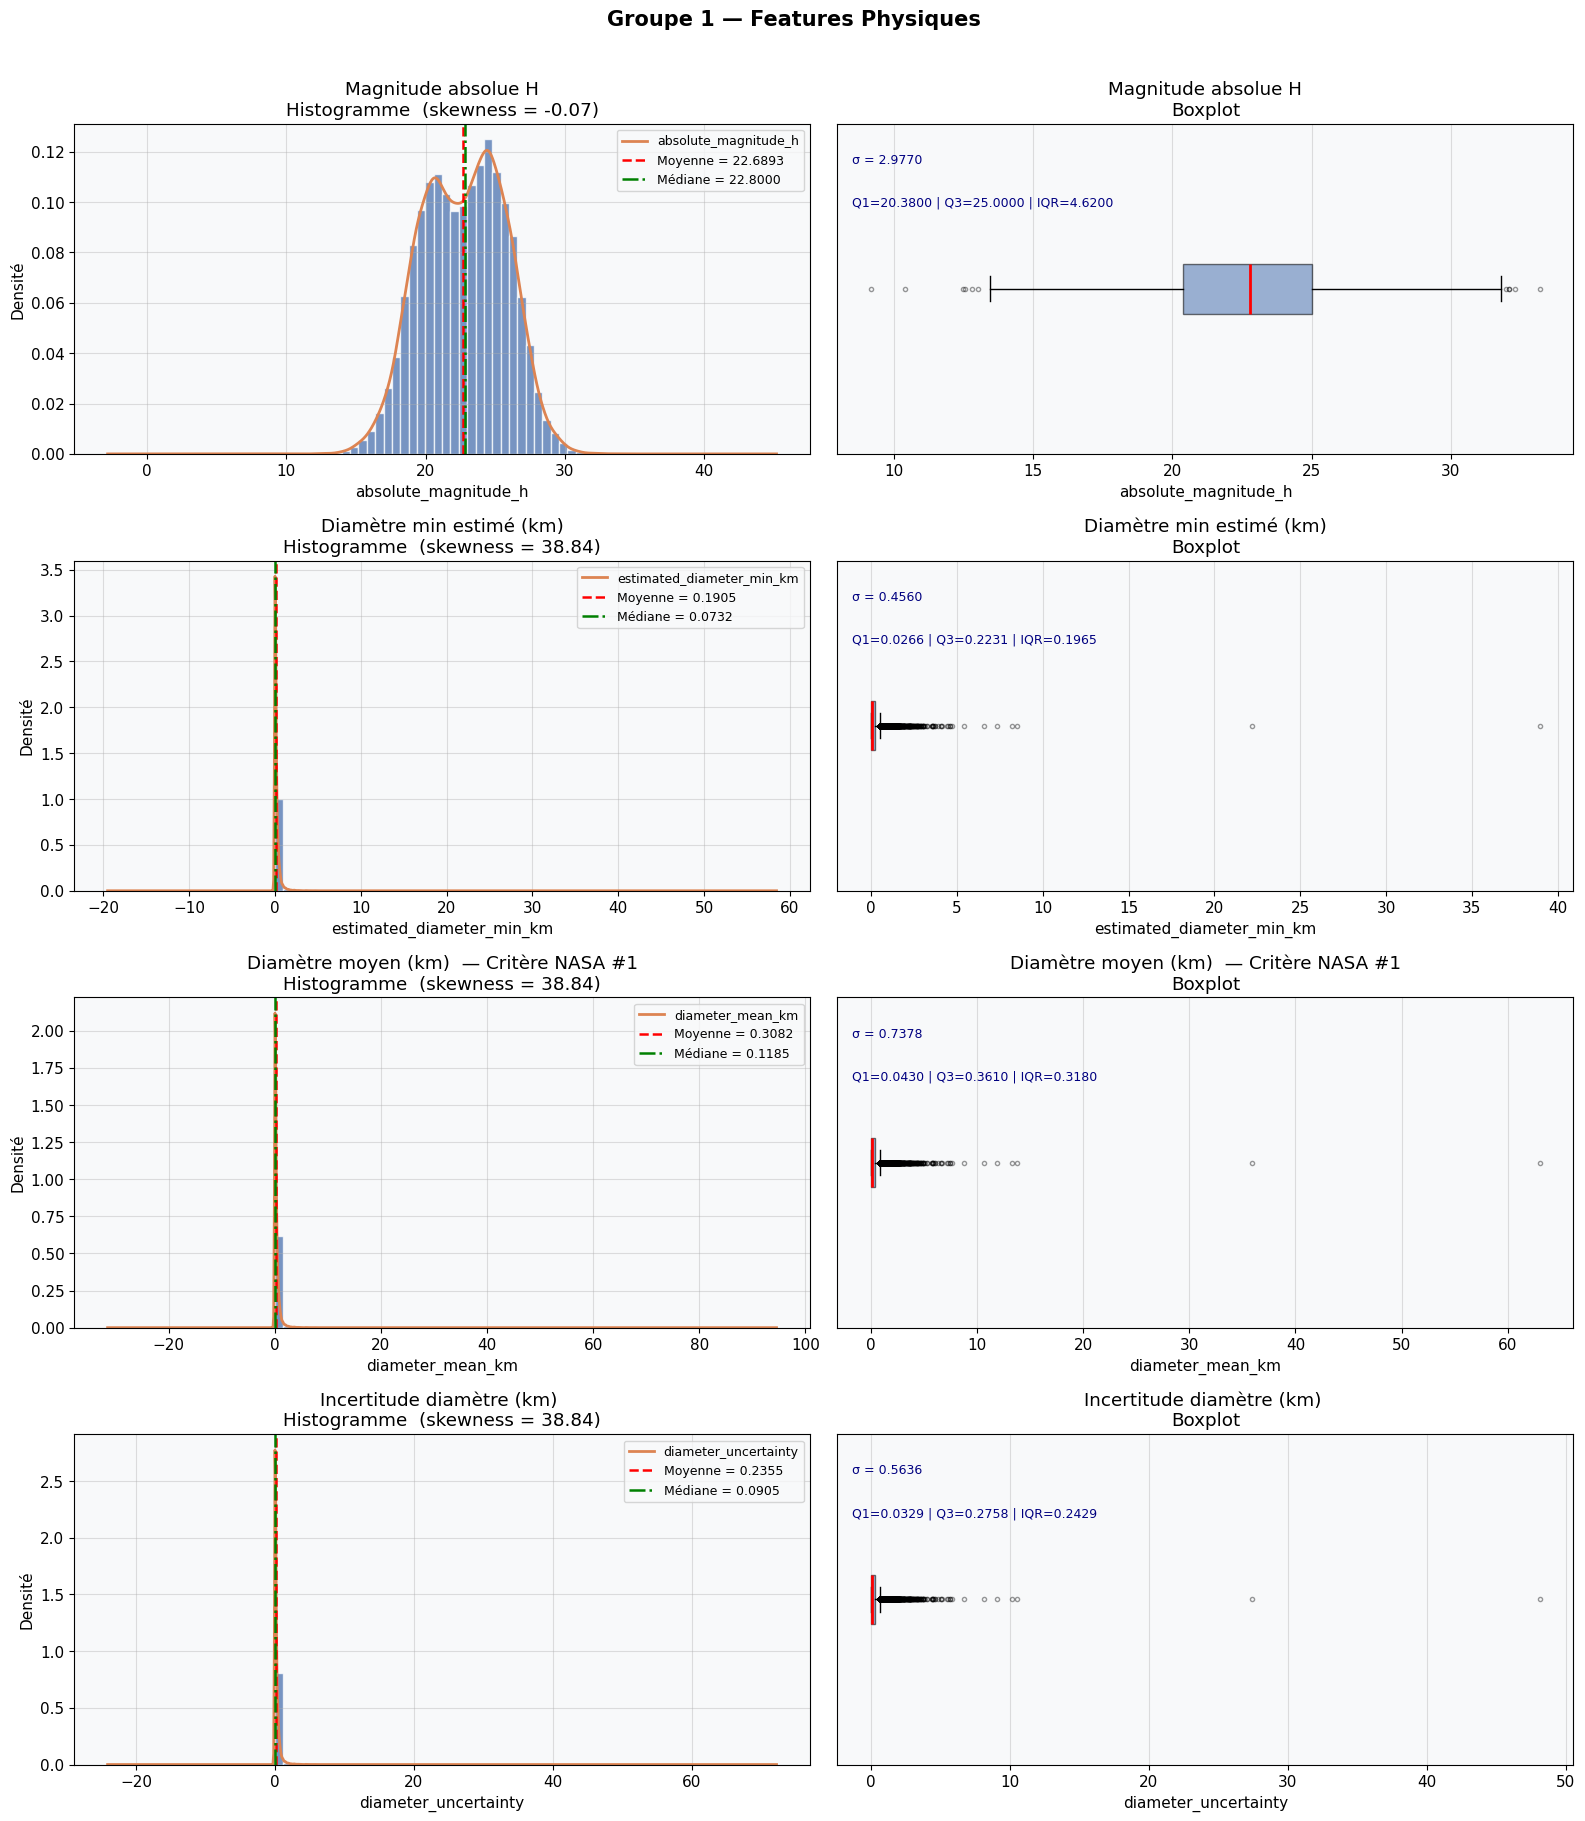

In [10]:
group1 = ["absolute_magnitude_h", "estimated_diameter_min_km",
          "diameter_mean_km", "diameter_uncertainty"]
group1_labels = {
    "absolute_magnitude_h":      "Magnitude absolue H",
    "estimated_diameter_min_km": "Diamètre min estimé (km)",
    "diameter_mean_km":          "Diamètre moyen (km)  — Critère NASA #1",
    "diameter_uncertainty":      "Incertitude diamètre (km) ",
}

fig, axes = plt.subplots(len(group1), 2, figsize=(16, 4.5 * len(group1)))
fig.suptitle("Groupe 1 — Features Physiques", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(group1):
    s = df[col].dropna()
    label = group1_labels[col]

    # Histogramme + KDE
    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#4C72B0", alpha=0.75, edgecolor="white", density=True)
    s.plot.kde(ax=ax_h, color="#DD8452", lw=2)
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    # Boxplot
    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#4C72B0", alpha=0.55),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#DD8452"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="navy")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="navy")

plt.tight_layout()
plt.show()


---
### Groupe 2 - Features d'Approche

| Variable | Description |
|----------|-------------|
| `relative_velocity_km_per_second` | Vitesse relative lors de l'approche la plus récente (km/s) |
| `miss_distance_astronomical` | Distance de passage (UA) |
| `n_approaches` | Nombre total d'approches enregistrées |
| `min_miss_distance_au` | Distance minimale historique (UA) — proxy du MOID |
| `max_velocity_km_s` | Vitesse maximale historique (km/s) |


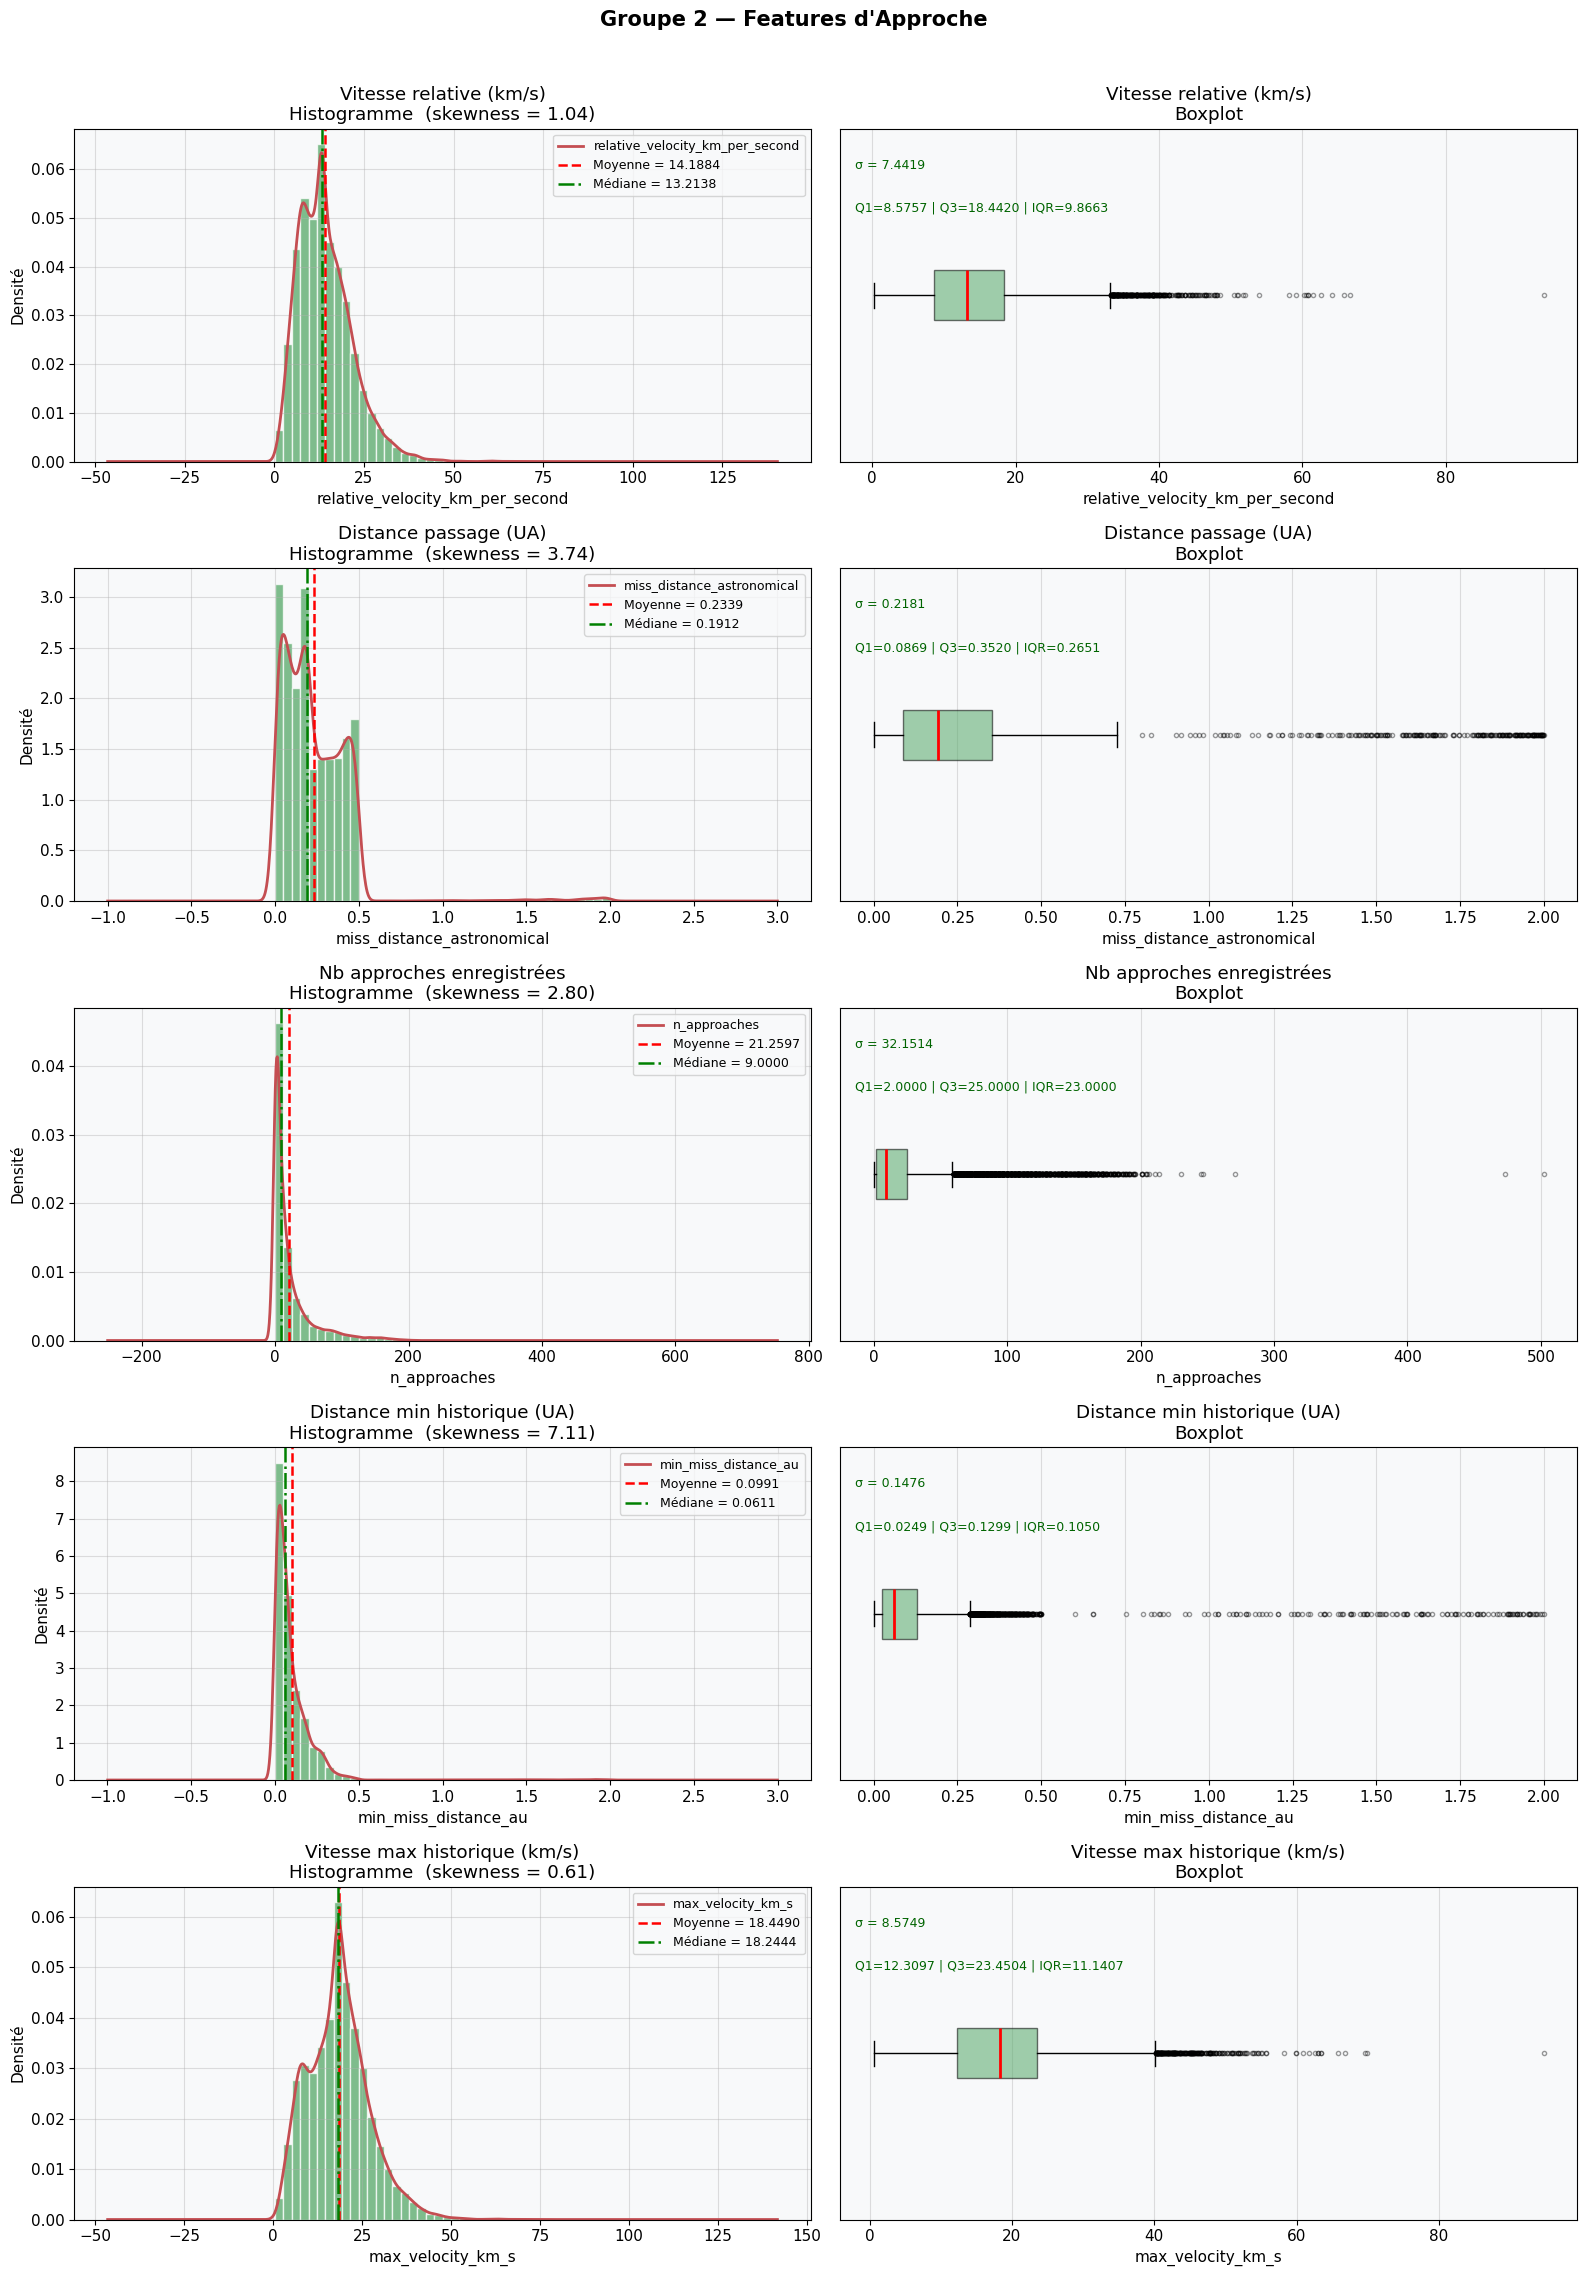

In [11]:
group2 = ["relative_velocity_km_per_second", "miss_distance_astronomical",
          "n_approaches", "min_miss_distance_au", "max_velocity_km_s"]
group2_labels = {
    "relative_velocity_km_per_second": "Vitesse relative (km/s)",
    "miss_distance_astronomical":      "Distance passage (UA)",
    "n_approaches":                    "Nb approches enregistrées",
    "min_miss_distance_au":            "Distance min historique (UA)",
    "max_velocity_km_s":               "Vitesse max historique (km/s)",
}

fig, axes = plt.subplots(len(group2), 2, figsize=(16, 4.5 * len(group2)))
fig.suptitle("Groupe 2 — Features d'Approche", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(group2):
    s = df[col].dropna()
    label = group2_labels[col]

    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#55A868", alpha=0.75, edgecolor="white", density=True)
    try: s.plot.kde(ax=ax_h, color="#C44E52", lw=2)
    except Exception: pass
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#55A868", alpha=0.55),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#C44E52"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="darkgreen")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="darkgreen")

plt.tight_layout()
plt.show()


---
### Groupe 3 - Features Orbitales

| Variable | Description |
|----------|-------------|
| `semi_major_axis` | Demi-grand axe (UA) |
| `eccentricity` | Excentricité [0–1] |
| `inclination` | Inclinaison (°) |
| `perihelion_distance` | Distance au périhélie (UA) |
| `aphelion_distance` | Distance à l'aphélie (UA) |
| `orbital_period` | Période orbitale (jours) |
| `perihelion_argument` | Argument du périhélie (°) |
| `orbit_uncertainty` | Code d'incertitude JPL (0–9) |
| `minimum_orbit_intersection` | **MOID (UA) — Critère NASA #2** (seuil : < 0,05 UA) |
| `data_arc_in_days` | Durée d'observation (jours) |


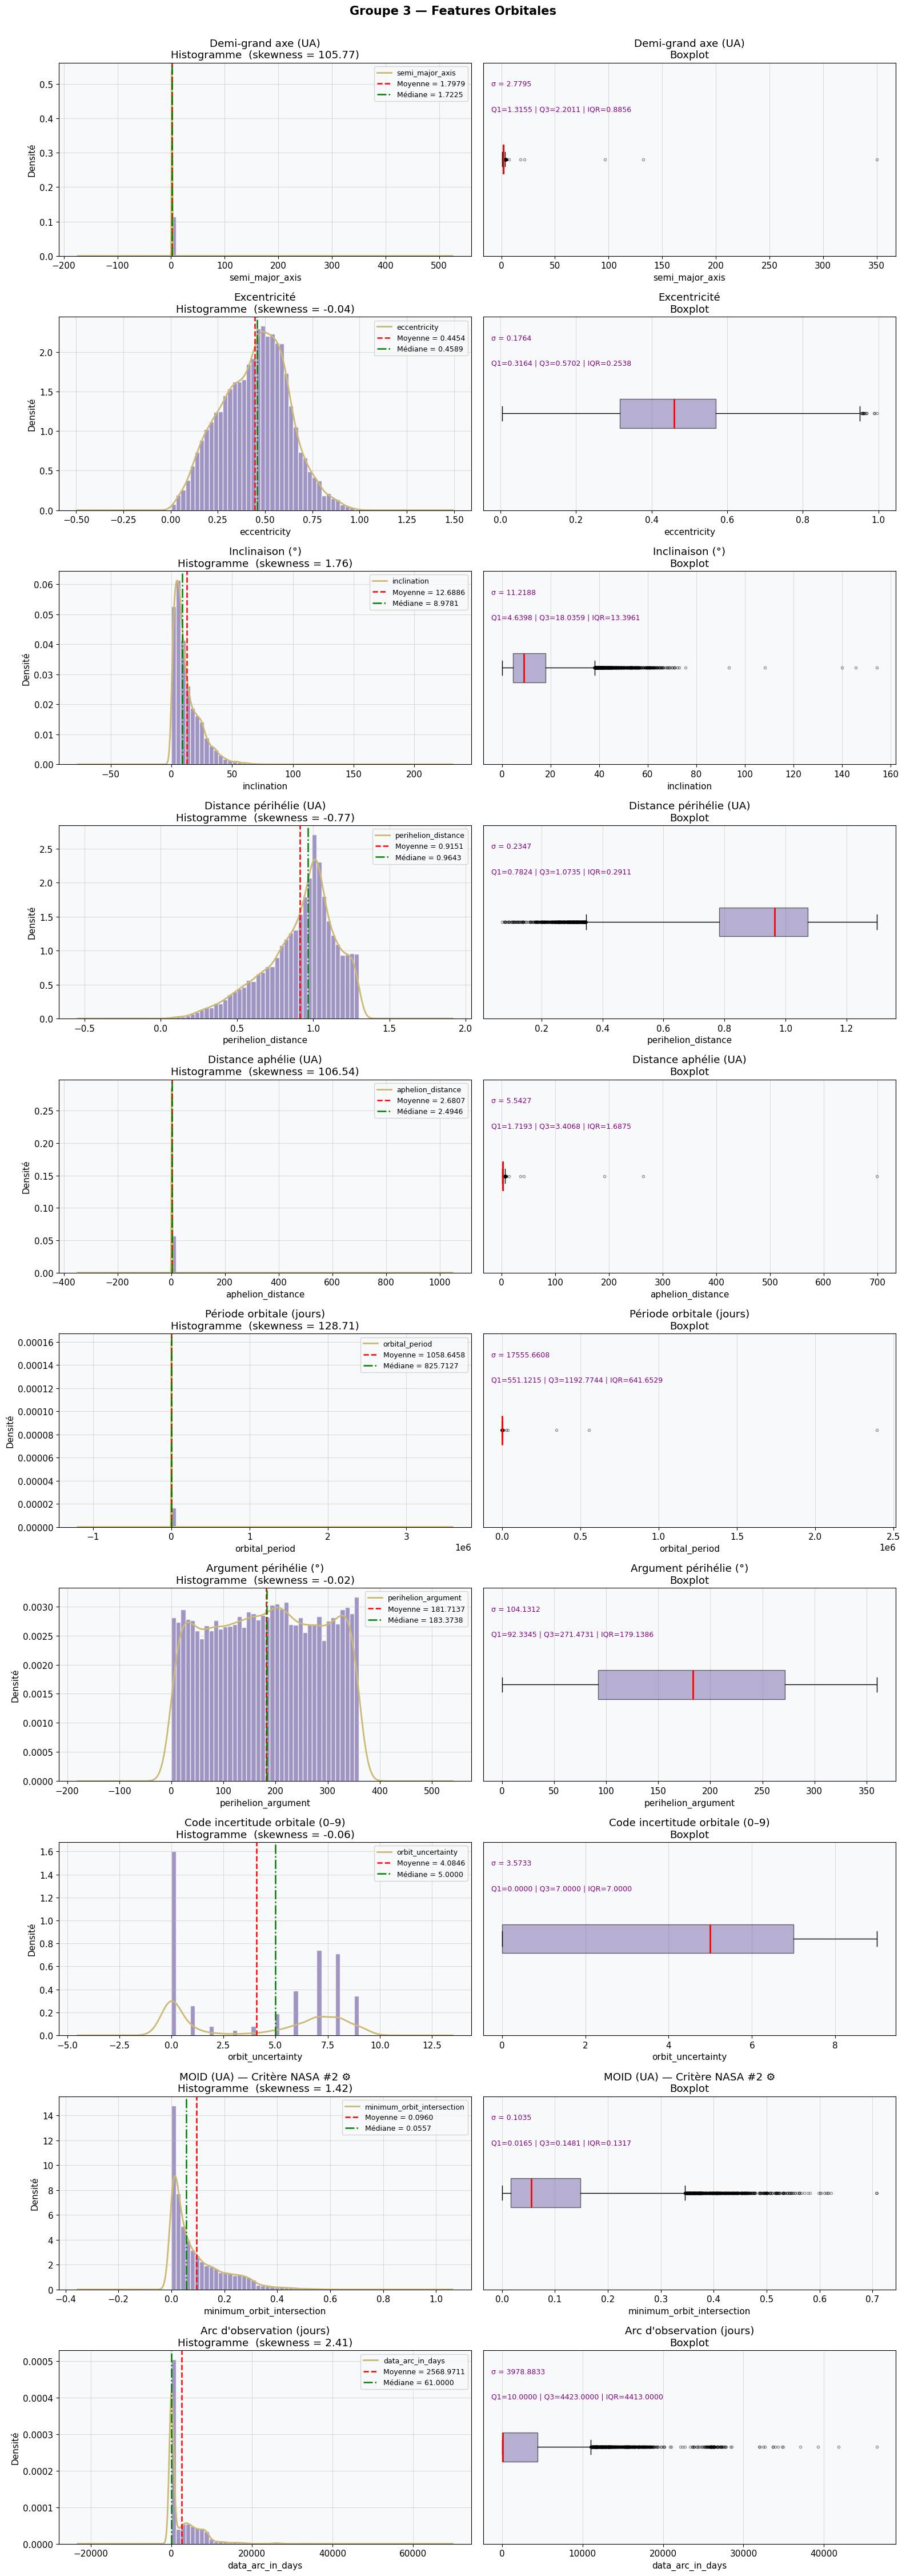

In [ ]:
group3 = ["semi_major_axis", "eccentricity", "inclination", "perihelion_distance",
          "aphelion_distance", "orbital_period", "perihelion_argument",
          "orbit_uncertainty", "minimum_orbit_intersection", "data_arc_in_days"]
group3_labels = {
    "semi_major_axis":           "Demi-grand axe (UA)",
    "eccentricity":              "Excentricité",
    "inclination":               "Inclinaison (°)",
    "perihelion_distance":       "Distance périhélie (UA)",
    "aphelion_distance":         "Distance aphélie (UA)",
    "orbital_period":            "Période orbitale (jours)",
    "perihelion_argument":       "Argument périhélie (°)",
    "orbit_uncertainty":         "Code incertitude orbitale (0–9)",
    "minimum_orbit_intersection":"MOID (UA) — Critère NASA #2 ",
    "data_arc_in_days":          "Arc d'observation (jours)",
}

fig, axes = plt.subplots(len(group3), 2, figsize=(16, 4.5 * len(group3)))
fig.suptitle("Groupe 3 — Features Orbitales", fontsize=15, fontweight="bold", y=1.001)

for i, col in enumerate(group3):
    s = df[col].dropna()
    label = group3_labels[col]

    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#8172B2", alpha=0.75, edgecolor="white", density=True)
    try: s.plot.kde(ax=ax_h, color="#CCB974", lw=2)
    except Exception: pass
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#8172B2", alpha=0.55),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#CCB974"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="purple")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="purple")

plt.tight_layout()
plt.show()


---
### Groupe 4 - Features Ingéniées

| Variable | Formule | Description |
|----------|---------|-------------|
| `perihelion_to_aphelion_ratio` | périhélie / aphélie | Forme orbitale — proche 0 = très elliptique |
| `threat_ratio` | MOID / diameter_mean | Indicateur composite de menace |
| `velocity_distance_ratio` | vitesse / distance | Énergie relative — élevé = rapide ET proche |
| `observation_reliability` | incertitude / arc_jours | Fiabilité des données orbitales |


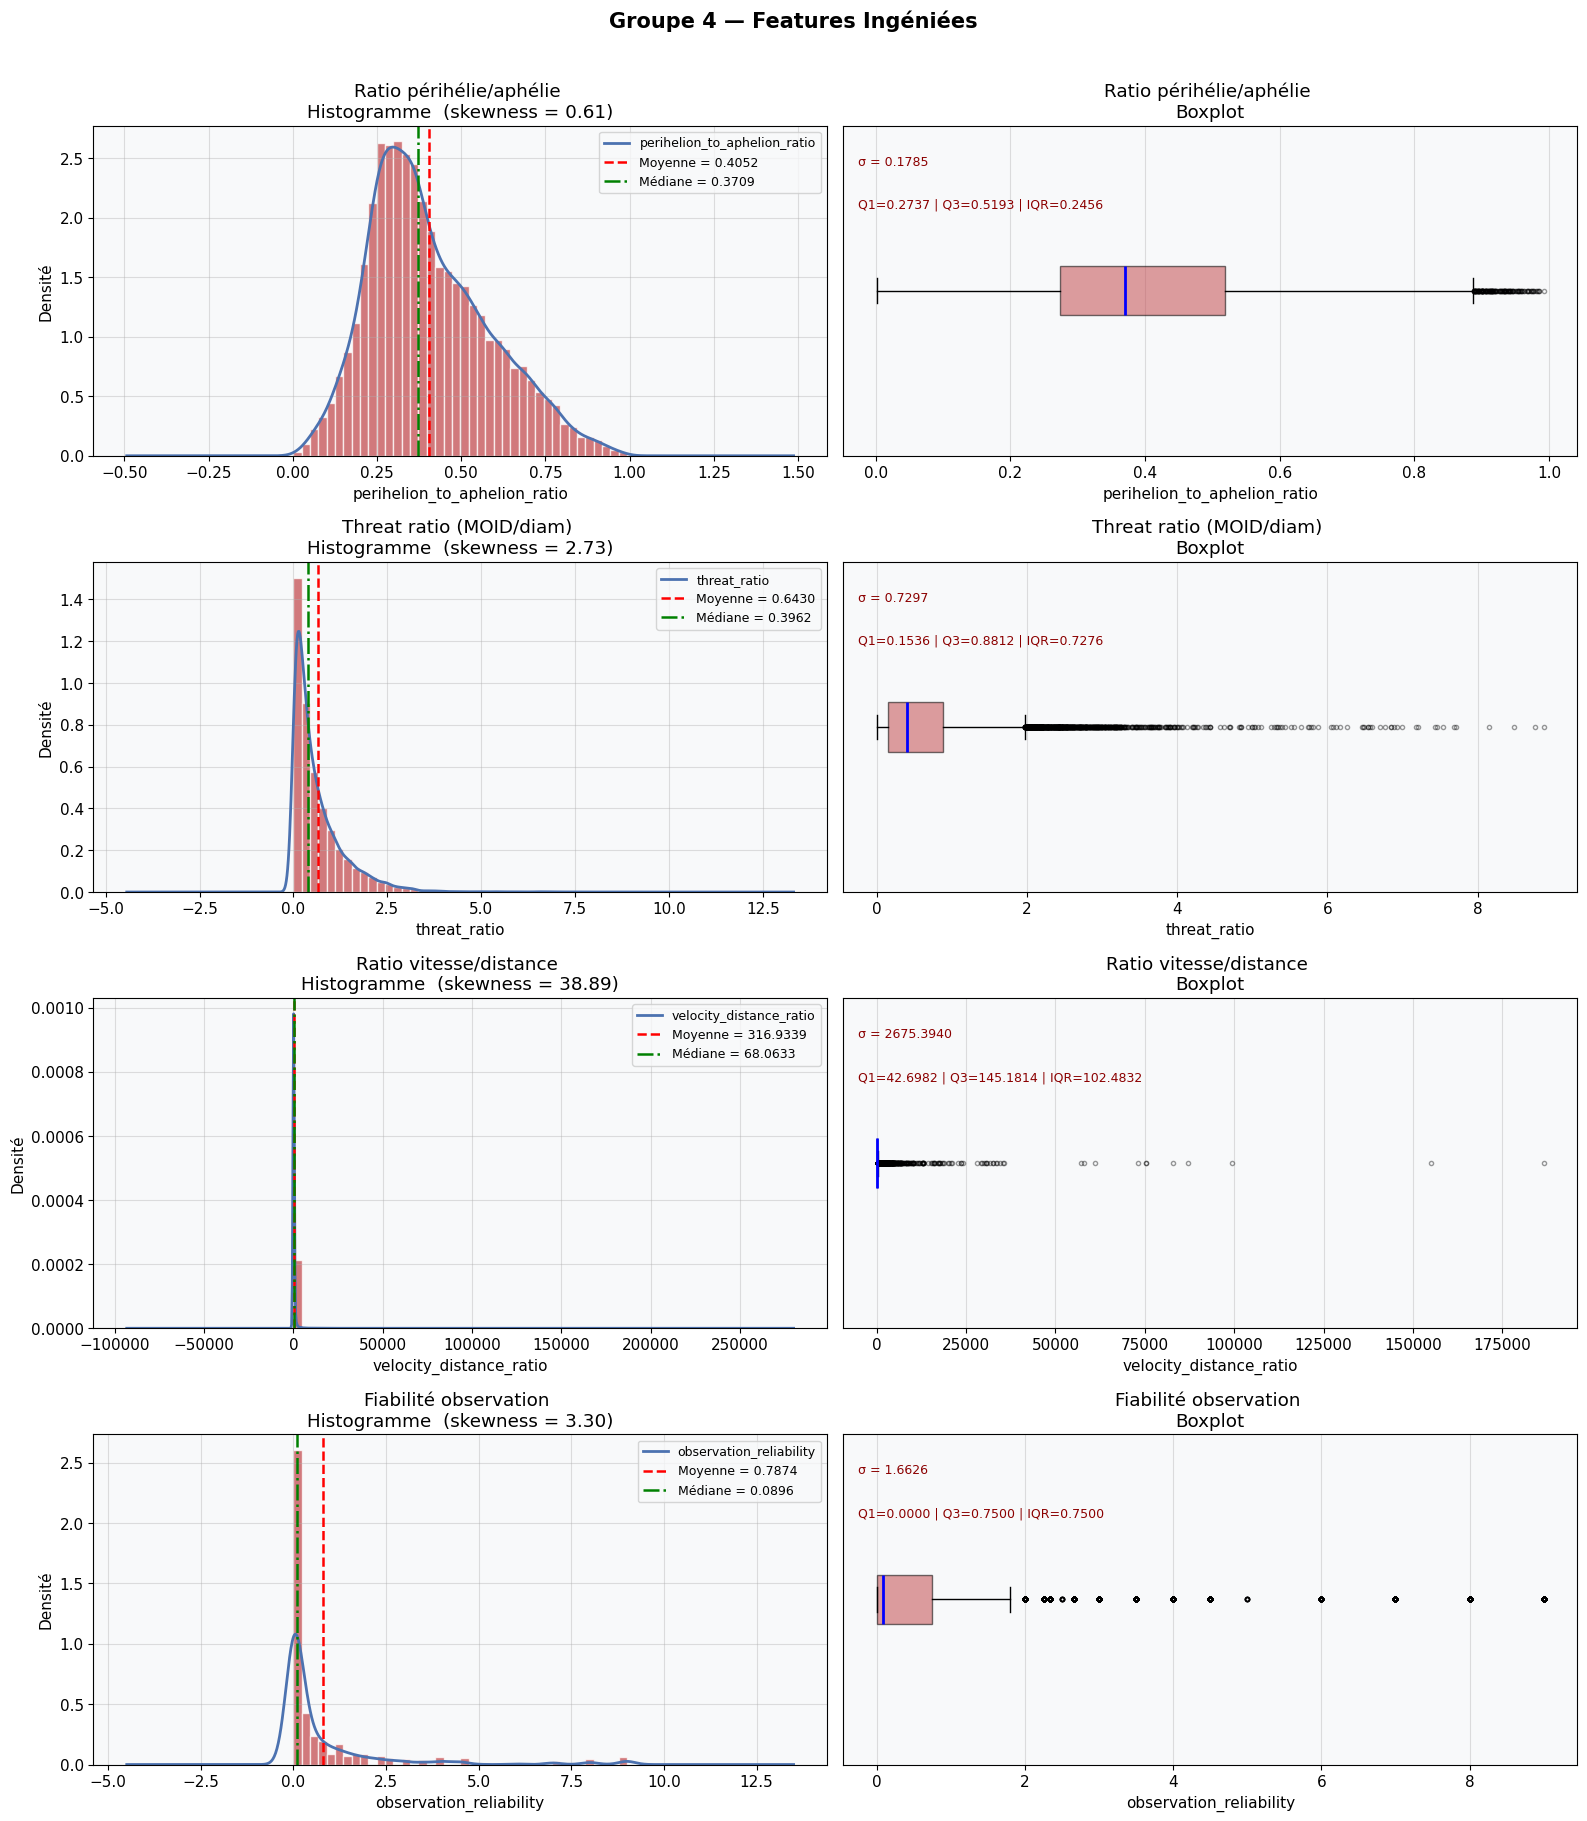

In [ ]:
group4 = ["perihelion_to_aphelion_ratio", "threat_ratio",
          "velocity_distance_ratio", "observation_reliability"]
group4_labels = {
    "perihelion_to_aphelion_ratio": "Ratio périhélie/aphélie ",
    "threat_ratio":                 "Threat ratio (MOID/diam) ",
    "velocity_distance_ratio":      "Ratio vitesse/distance ",
    "observation_reliability":      "Fiabilité observation ",
}

fig, axes = plt.subplots(len(group4), 2, figsize=(16, 4.5 * len(group4)))
fig.suptitle("Groupe 4 — Features Ingéniées", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(group4):
    s = df[col].dropna()
    label = group4_labels[col]

    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#C44E52", alpha=0.75, edgecolor="white", density=True)
    try: s.plot.kde(ax=ax_h, color="#4C72B0", lw=2)
    except Exception: pass
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#C44E52", alpha=0.55),
                 medianprops=dict(color="blue", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#4C72B0"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="darkred")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="darkred")

plt.tight_layout()
plt.show()


---
### Variables Binaires

`is_sentry_object` et `is_potentially_hazardous` sont des indicatrices 0/1 — un diagramme en barres est plus adapté qu'un histogramme continu.


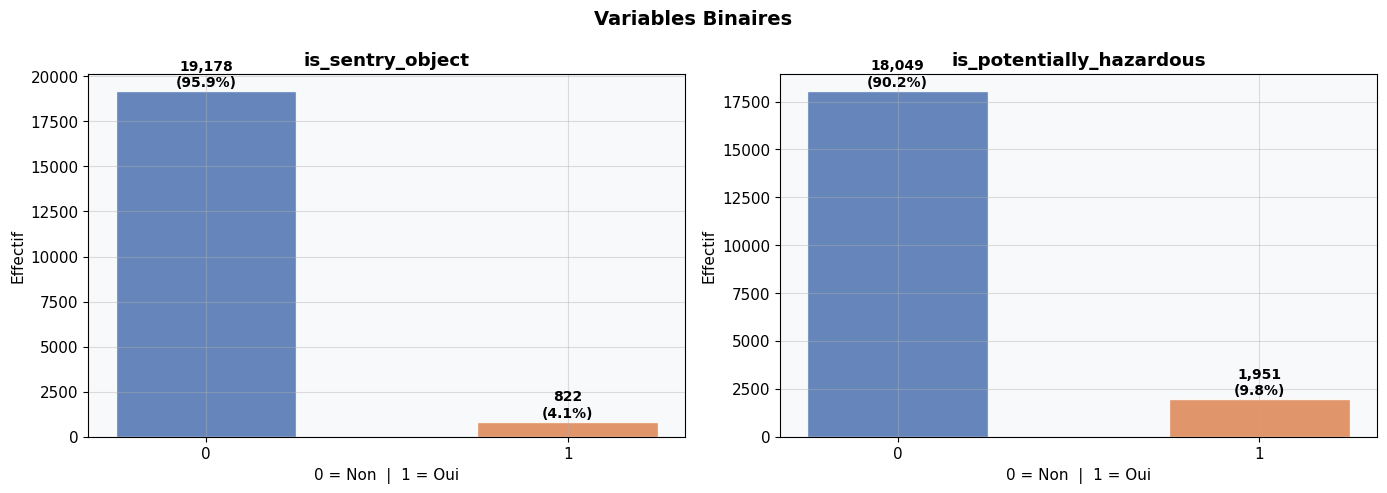

In [15]:
binary_display = [c for c in binary_cols if c in df.columns]

fig, axes = plt.subplots(1, len(binary_display), figsize=(7 * len(binary_display), 5))
if len(binary_display) == 1:
    axes = [axes]

for ax, col in zip(axes, binary_display):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vc.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
                f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel("0 = Non  |  1 = Oui")
    ax.set_ylabel("Effectif")

plt.suptitle("Variables Binaires", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
### Variables Catégorielles

Une modalité est **rare** si sa fréquence relative est **< 1 %** de l'ensemble du dataset.


 Modalités rares dans 'orbiting_body' :
   VENUS          :   125 (0.62%)
   MERC           :    75 (0.38%)
   MOON           :     1 (0.01%)
 Modalités rares dans 'orbit_class_type' :
   IEO            :    18 (0.09%)


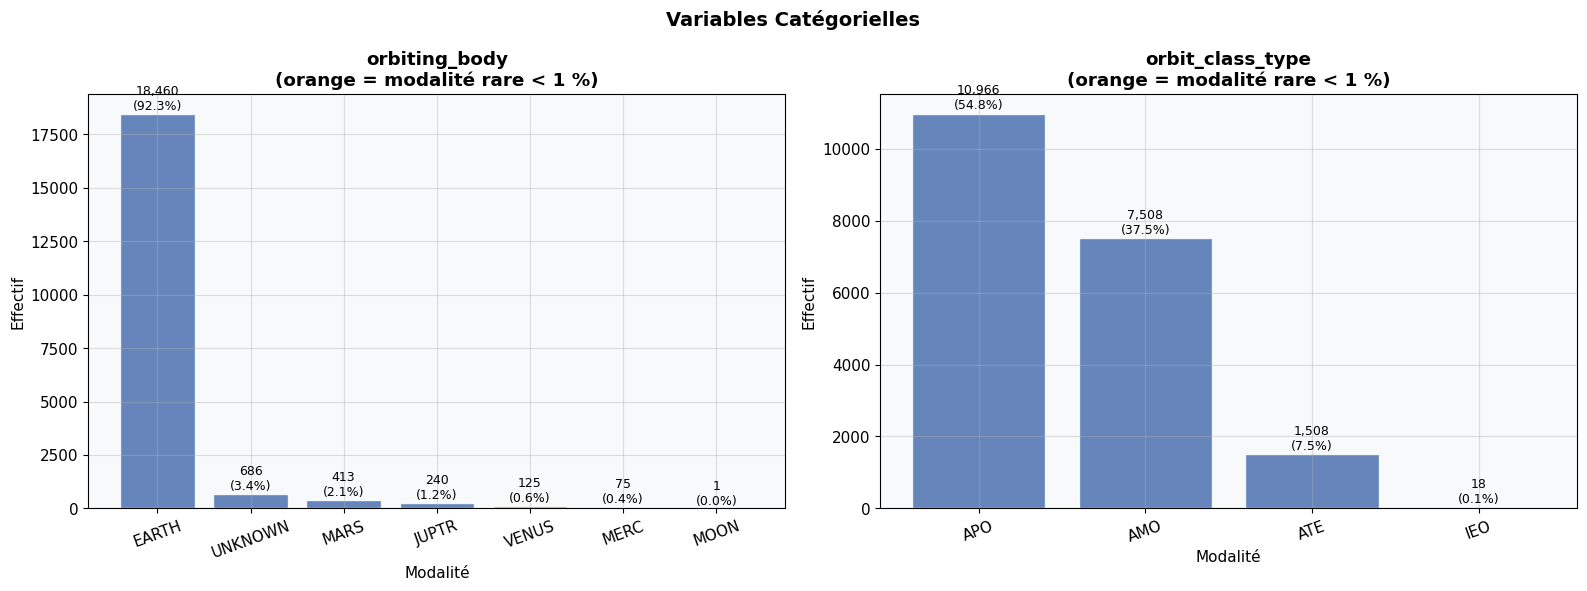

In [16]:
RARE_THRESHOLD = 0.01

fig, axes = plt.subplots(1, len(cat_cols), figsize=(8 * len(cat_cols), 6))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc     = df[col].value_counts(normalize=False).sort_values(ascending=False)
    vc_pct = vc / len(df)
    colors = ["#DD8452" if p < RARE_THRESHOLD else "#4C72B0" for p in vc_pct]

    bars = ax.bar(vc.index, vc.values, color=colors, alpha=0.85, edgecolor="white")
    for bar, (mod, cnt) in zip(bars, vc.items()):
        pct = cnt / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.003,
                f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{col}\n(orange = modalité rare < 1 %)", fontweight="bold")
    ax.set_xlabel("Modalité"); ax.set_ylabel("Effectif")
    ax.tick_params(axis="x", rotation=20)

    rares = vc[vc_pct < RARE_THRESHOLD]
    if not rares.empty:
        print(f" Modalités rares dans '{col}' :")
        for mod, cnt in rares.items():
            print(f"   {mod:15s}: {cnt:5d} ({cnt/len(df)*100:.2f}%)")
    else:
        print(f" Aucune modalité rare dans '{col}'.")

plt.suptitle("Variables Catégorielles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [17]:
# Tableau récapitulatif catégorielles
for col in cat_cols:
    vc     = df[col].value_counts(normalize=False)
    vc_pct = df[col].value_counts(normalize=True)
    print(f"\n▸ {col}  —  {df[col].nunique()} modalités distinctes")
    summary = pd.DataFrame({
        "Effectif":       vc,
        "Fréquence (%)":  (vc_pct * 100).round(2),
        "Rare (< 1%)":    vc_pct < 0.01,
    })
    print(summary.to_string())



▸ orbiting_body  —  7 modalités distinctes
               Effectif  Fréquence (%)  Rare (< 1%)
orbiting_body                                      
EARTH             18460          92.30        False
UNKNOWN             686           3.43        False
MARS                413           2.07        False
JUPTR               240           1.20        False
VENUS               125           0.62         True
MERC                 75           0.38         True
MOON                  1           0.00         True

▸ orbit_class_type  —  4 modalités distinctes
                  Effectif  Fréquence (%)  Rare (< 1%)
orbit_class_type                                      
APO                  10966          54.83        False
AMO                   7508          37.54        False
ATE                   1508           7.54        False
IEO                     18           0.09         True


---
### Synthèse de cette section

**Variables continues :**
- La majorité des variables présentent une **forte asymétrie droite** (skewness > 1), notamment `diameter_mean_km`, `n_approaches`, `velocity_distance_ratio`, `aphelion_distance` → transformation logarithmique recommandée avant StandardScaler pour les modèles sensibles à l'échelle (LR, SVM, KNN).
- Les **outliers IQR sont nombreux** mais physiquement valides (grands astéroïdes, vitesses élevées) → à conserver en Phase 2.2 ; RobustScaler préférable à StandardScaler pour la plupart des variables.
- `minimum_orbit_intersection` (MOID) et `diameter_mean_km` sont les deux variables encodant directement les critères NASA — distributions très distinctives attendues entre classes PHA / non-PHA (à confirmer par Membre B en bivariée).
- `orbit_uncertainty` est quasi-constante à 0 pour la majorité des objets → faible variance, à surveiller lors de la sélection de features.

**Variables catégorielles :**
- `orbiting_body` : présence probable de modalités rares sur le dataset complet (MOON, MERC, UNKNOWN < 1 %) → regrouper en catégorie "AUTRE" avant One-Hot Encoding.
- `orbit_class_type` : 4 modalités propres (AMO, APO, ATE, IEO) — One-Hot Encoding standard, cardinalité faible.

**Variables binaires :**
- `is_sentry_object` : quasi-exclusivement 0 sur le dataset → variable à faible variance, peu discriminante seule.
- `is_potentially_hazardous` : variable cible — déséquilibre ~90 % / ~10 % confirmé.

>  **Section 2.1.a terminée.** Membre B peut démarrer la section 2.1.b (EDA bivariée).

---
*— Section suivante : 2.1.b Exploration Bivariée (Membre B — El Allouche Zakariyae) —*
